# 🧹 Clase 3 — Limpieza y Preparación de Datos

**Curso:** Introducción a la Ciencia de Datos  
**Sesión:** 3 de 8  
**Herramientas:** Python · pandas · numpy · scikit-learn

---

## Objetivos de esta clase

Al terminar esta sesión vas a poder:

1. Diagnosticar sistemáticamente la calidad de un dataset (nulos, duplicados, inconsistencias, outliers)
2. Aplicar estrategias adecuadas de tratamiento de nulos, desde eliminación hasta imputación avanzada
3. Detectar y decidir qué hacer con valores atípicos (outliers)
4. Codificar variables categóricas con Label Encoding y One-Hot Encoding
5. Normalizar y estandarizar variables numéricas
6. Crear variables derivadas (feature engineering básico)
7. Construir un pipeline de preprocesamiento con scikit-learn
8. Aplicar todo esto a tu propio dataset con una checklist guiada

---

> 💡 **Sobre esta clase:** Es la más larga y más práctica del curso. La limpieza de datos ocupa entre el 60 y el 80% del tiempo real en cualquier proyecto de datos. No es glamorosa, pero es donde se gana o se pierde la calidad del análisis.

## ⚙️ Sección 0 — Setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder,
    MinMaxScaler, StandardScaler
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.3f}'.format)

print('✅ Setup completo.')

✅ Setup completo.


## 🏗️ Dataset de trabajo

Usaremos un dataset sintético de **postulantes a un programa de becas universitarias**. Tiene los tipos de problemas que aparecen en datos reales: nulos con patrones, outliers, inconsistencias de texto, fechas mal tipificadas y variables que necesitan ingeniería.

In [3]:
np.random.seed(2024)
n = 300

regiones = ['Metropolitana', 'Valparaíso', 'Biobío', 'Araucanía', 'Antofagasta']
carreras = ['Ingeniería', 'Medicina', 'Derecho', 'Pedagogía', 'Arte']
tipos_colegio = ['Municipal', 'Particular Subvencionado', 'Particular Pagado']

df_raw = pd.DataFrame({
    'id':               range(1, n + 1),
    'nombre':           [f'Postulante_{i:03d}' for i in range(1, n + 1)],
    'fecha_nacimiento': pd.date_range('1998-01-01', periods=n, freq='7D').strftime('%d/%m/%Y'),
    'region':           np.random.choice(regiones, n),
    'carrera':          np.random.choice(carreras, n),
    'tipo_colegio':     np.random.choice(tipos_colegio, n, p=[0.45, 0.40, 0.15]),
    'puntaje_nem':      np.random.normal(550, 80, n).clip(150, 850).round(1),
    'puntaje_ranking':  np.random.normal(560, 75, n).clip(150, 850).round(1),
    'ingreso_familiar': np.random.choice(
        [350000, 500000, 700000, 1000000, 1500000, 2500000], n,
        p=[0.20, 0.25, 0.25, 0.15, 0.10, 0.05]),
    'n_hermanos':       np.random.choice([0, 1, 2, 3, 4, 5], n, p=[0.10, 0.25, 0.30, 0.20, 0.10, 0.05]),
    'trabaja':          np.random.choice(['Sí', 'No'], n, p=[0.35, 0.65]),
    'seleccionado':     np.random.choice([0, 1], n, p=[0.70, 0.30]),
})

# ─── Inyectar problemas realistas ───────────────────────────────────────────

# Nulos no aleatorios: postulantes de colegios particulares pagados tienen
# más probabilidad de no reportar ingreso familiar
mask_pagado = df_raw['tipo_colegio'] == 'Particular Pagado'
idx_nulos_ingreso = df_raw[mask_pagado].sample(frac=0.4, random_state=1).index
df_raw.loc[idx_nulos_ingreso, 'ingreso_familiar'] = np.nan

# Nulos aleatorios en puntajes y hermanos
for col, frac in [('puntaje_nem', 0.07), ('puntaje_ranking', 0.05), ('n_hermanos', 0.06)]:
    idx = df_raw.sample(frac=frac, random_state=42).index
    df_raw.loc[idx, col] = np.nan

# Inconsistencias de texto
df_raw.loc[[10, 45, 92], 'region']   = ['metropolitana', 'VALPARAÍSO', 'biobío']
df_raw.loc[[20, 67],     'trabaja']  = ['si', 'NO']
df_raw.loc[[5, 30],      'carrera']  = ['ingeniería', 'MEDICINA']

# Outliers extremos
df_raw.loc[15, 'puntaje_nem']      = 1200   # imposible (máx real = 850)
df_raw.loc[88, 'ingreso_familiar'] = 50000000  # veinte veces el máximo esperado
df_raw.loc[120, 'n_hermanos']      = 25     # imposible

# Duplicados
df_raw = pd.concat([df_raw, df_raw.iloc[[0, 1, 2]]], ignore_index=True)

# fecha_nacimiento como string (no datetime)
# ya está como string — es intencional para practicar conversión

print(f'Dataset creado: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas')
print('(contiene nulos, outliers, duplicados e inconsistencias de texto)')
df_raw.head()

Dataset creado: 303 filas × 12 columnas
(contiene nulos, outliers, duplicados e inconsistencias de texto)


,id,nombre,fecha_nacimiento,region,carrera,tipo_colegio,puntaje_nem,puntaje_ranking,ingreso_familiar,n_hermanos,trabaja,seleccionado
0,1,Postulante_001,01/01/1998,Metropolitana,Ingeniería,Particular Subvencionado,592.800,638.000,1000000.000,0.000,Sí,0
1,2,Postulante_002,08/01/1998,Biobío,Ingeniería,Particular Subvencionado,331.000,533.100,350000.000,4.000,Sí,0
2,3,Postulante_003,15/01/1998,Metropolitana,Ingeniería,Municipal,564.800,539.100,1500000.000,4.000,No,0
3,4,Postulante_004,22/01/1998,Metropolitana,Medicina,Municipal,667.500,479.300,500000.000,1.000,No,0
4,5,Postulante_005,29/01/1998,Araucanía,Arte,Particular Subvencionado,437.200,516.300,700000.000,3.000,No,0


---

## 🩺 Sección 1 — Diagnóstico de Calidad

Antes de limpiar, hay que saber qué limpiar. Un diagnóstico incompleto genera limpiezas incorrectas.

```
DIAGNÓSTICO
  ├── 1A. Nulos      → ¿cuántos? ¿dónde? ¿tienen patrón?
  ├── 1B. Duplicados → ¿filas completas? ¿claves repetidas?
  ├── 1C. Tipos      → ¿algo que debería ser número es texto?
  ├── 1D. Inconsist. → ¿misma categoría escrita de distintas formas?
  └── 1E. Outliers   → ¿valores fuera del rango posible o esperado?
```

In [4]:
# 1A — Mapa completo de nulos
nulos = df_raw.isnull().sum()
pct   = (nulos / len(df_raw) * 100).round(1)

reporte = pd.DataFrame({
    'Nulos': nulos,
    '%': pct,
    'Tipo': df_raw.dtypes,
    'Únicos': df_raw.nunique()
}).sort_values('Nulos', ascending=False)

print('=== REPORTE DE NULOS ===')
print(reporte.to_string())

=== REPORTE DE NULOS ===
                  Nulos     %     Tipo  Únicos
puntaje_nem          21 6.900  float64     258
n_hermanos           18 5.900  float64       7
ingreso_familiar     16 5.300  float64       7
puntaje_ranking      15 5.000  float64     272
region                0 0.000   object       8
fecha_nacimiento      0 0.000   object     300
nombre                0 0.000   object     300
id                    0 0.000    int64     300
carrera               0 0.000   object       7
tipo_colegio          0 0.000   object       3
trabaja               0 0.000   object       4
seleccionado          0 0.000    int64       2


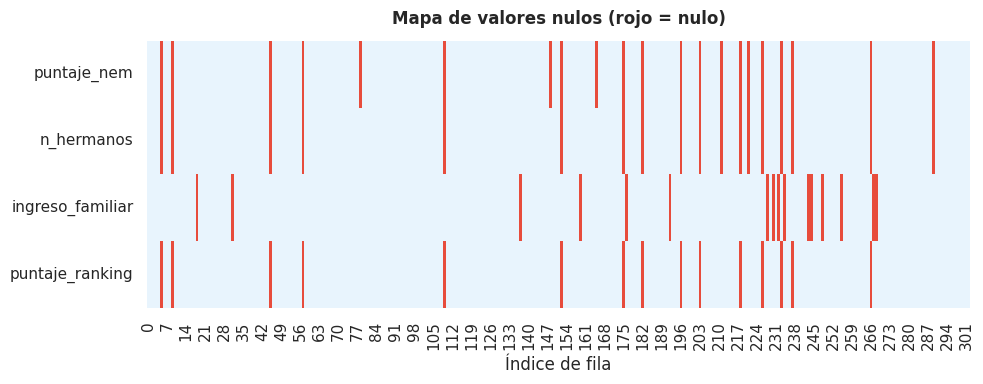


¿Ingreso familiar nulo correlaciona con tipo de colegio?
tipo_colegio
Municipal                    0 nulos de 137 (0%)
Particular Pagado           16 nulos de 39 (41%)
Particular Subvencionado     0 nulos de 127 (0%)
Name: ingreso_familiar, dtype: object


In [5]:
# Visualización del patrón de nulos
# ¿Son aleatorios o siguen un patrón?

cols_con_nulos = reporte[reporte['Nulos'] > 0].index.tolist()

fig, ax = plt.subplots(figsize=(10, 4))
mascara = df_raw[cols_con_nulos].isnull().astype(int)
sns.heatmap(mascara.T, cmap=['#e8f4fd', '#e74c3c'],
            cbar=False, yticklabels=cols_con_nulos, ax=ax)
ax.set_title('Mapa de valores nulos (rojo = nulo)', fontweight='bold', pad=12)
ax.set_xlabel('Índice de fila')
plt.tight_layout()
plt.show()

print()
print('¿Ingreso familiar nulo correlaciona con tipo de colegio?')
print(df_raw.groupby('tipo_colegio')['ingreso_familiar'].apply(
    lambda x: f'{x.isnull().sum()} nulos de {len(x)} ({x.isnull().mean()*100:.0f}%)'
))

In [6]:
# 1B — Duplicados
n_dup_total = df_raw.duplicated().sum()
n_dup_id    = df_raw.duplicated(subset='id').sum()

print(f'Filas completamente duplicadas: {n_dup_total}')
print(f'IDs duplicados:                 {n_dup_id}')
print()

if n_dup_total > 0:
    print('Ejemplo de filas duplicadas:')
    print(df_raw[df_raw.duplicated(keep=False)].sort_values('id').head(6))

Filas completamente duplicadas: 3
IDs duplicados:                 3

Ejemplo de filas duplicadas:
     id          nombre fecha_nacimiento         region     carrera  \
0     1  Postulante_001       01/01/1998  Metropolitana  Ingeniería   
300   1  Postulante_001       01/01/1998  Metropolitana  Ingeniería   
1     2  Postulante_002       08/01/1998         Biobío  Ingeniería   
301   2  Postulante_002       08/01/1998         Biobío  Ingeniería   
2     3  Postulante_003       15/01/1998  Metropolitana  Ingeniería   
302   3  Postulante_003       15/01/1998  Metropolitana  Ingeniería   

                 tipo_colegio  puntaje_nem  puntaje_ranking  ingreso_familiar  \
0    Particular Subvencionado      592.800          638.000       1000000.000   
300  Particular Subvencionado      592.800          638.000       1000000.000   
1    Particular Subvencionado      331.000          533.100        350000.000   
301  Particular Subvencionado      331.000          533.100        350000.000   

In [7]:
# 1C y 1D — Tipos e inconsistencias en columnas categóricas
print('=== TIPOS DE DATOS ===')
print(df_raw.dtypes)
print()
print('⚠️  fecha_nacimiento debería ser datetime, no object')
print()

print('=== INCONSISTENCIAS EN COLUMNAS CATEGÓRICAS ===')
for col in ['region', 'carrera', 'tipo_colegio', 'trabaja']:
    vals = sorted(df_raw[col].dropna().unique())
    print(f'\n{col}:')
    for v in vals:
        print(f'  {repr(v)}')

=== TIPOS DE DATOS ===
id                    int64
nombre               object
fecha_nacimiento     object
region               object
carrera              object
tipo_colegio         object
puntaje_nem         float64
puntaje_ranking     float64
ingreso_familiar    float64
n_hermanos          float64
trabaja              object
seleccionado          int64
dtype: object

⚠️  fecha_nacimiento debería ser datetime, no object

=== INCONSISTENCIAS EN COLUMNAS CATEGÓRICAS ===

region:
  'Antofagasta'
  'Araucanía'
  'Biobío'
  'Metropolitana'
  'VALPARAÍSO'
  'Valparaíso'
  'biobío'
  'metropolitana'

carrera:
  'Arte'
  'Derecho'
  'Ingeniería'
  'MEDICINA'
  'Medicina'
  'Pedagogía'
  'ingeniería'

tipo_colegio:
  'Municipal'
  'Particular Pagado'
  'Particular Subvencionado'

trabaja:
  'NO'
  'No'
  'Sí'
  'si'


In [8]:
# 1E — Outliers: rango de columnas numéricas
cols_num = ['puntaje_nem', 'puntaje_ranking', 'ingreso_familiar', 'n_hermanos']

print('=== RANGOS NUMÉRICOS ===')
print(f'{"Columna":<22} {"Min":>12} {"Max":>14} {"Esperado"}')
print('-' * 70)
rangos_esperados = {
    'puntaje_nem':      (150, 850,    '150 – 850'),
    'puntaje_ranking':  (150, 850,    '150 – 850'),
    'ingreso_familiar': (0,   5000000,'0 – ~5.000.000'),
    'n_hermanos':       (0,   10,     '0 – 10'),
}
for col in cols_num:
    mn = df_raw[col].min()
    mx = df_raw[col].max()
    exp_min, exp_max, exp_str = rangos_esperados[col]
    flag = ' 🚨' if mn < exp_min or mx > exp_max else ''
    print(f'{col:<22} {mn:>12,.1f} {mx:>14,.1f}   {exp_str}{flag}')

=== RANGOS NUMÉRICOS ===
Columna                         Min            Max Esperado
----------------------------------------------------------------------
puntaje_nem                   331.0        1,200.0   150 – 850 🚨
puntaje_ranking               310.8          816.8   150 – 850
ingreso_familiar          350,000.0   50,000,000.0   0 – ~5.000.000 🚨
n_hermanos                      0.0           25.0   0 – 10 🚨


---

## 🩹 Sección 2 — Tratamiento de Nulos

No existe una estrategia universal. La elección depende de tres factores:

```
¿Cuántos nulos hay?          ¿Por qué faltan?          ¿Qué harás después?
─────────────────────        ────────────────           ──────────────────
> 50% → considera eliminar   MCAR: aleatorios           Modelo sensible a
20-50% → imputación avanzada MAR:  dependen de otra     outliers → mediana
< 20% → imputación simple    MNAR: dependen del valor   Modelo lineal → media
```

Vamos a trabajar sobre una copia limpia del dataset.

In [9]:
# Trabajamos siempre sobre copias — nunca modifiques el dataset original
df = df_raw.copy()
print(f'Copia creada: {df.shape}')

Copia creada: (303, 12)


In [10]:
# OPCIÓN 1: Eliminar filas con nulos
# Úsala cuando los nulos son pocos Y aleatorios

df_sin_nulos = df.dropna()
print(f'Original:         {len(df):>4} filas')
print(f'Tras dropna():    {len(df_sin_nulos):>4} filas')
print(f'Filas eliminadas: {len(df) - len(df_sin_nulos):>4} ({(len(df)-len(df_sin_nulos))/len(df)*100:.1f}%)')
print()
print('⚠️  Perderíamos el 30%+ de los datos — NO es la mejor opción aquí.')

Original:          303 filas
Tras dropna():     266 filas
Filas eliminadas:   37 (12.2%)

⚠️  Perderíamos el 30%+ de los datos — NO es la mejor opción aquí.


In [11]:
# OPCIÓN 2: Eliminar columnas con demasiados nulos
# Regla de pulgar: > 50% nulos → considerar eliminar la columna

umbral = 0.50
pct_nulos_col = df.isnull().mean()
cols_eliminar = pct_nulos_col[pct_nulos_col > umbral].index.tolist()

if cols_eliminar:
    print(f'Columnas con > {umbral*100:.0f}% nulos (candidatas a eliminar): {cols_eliminar}')
else:
    print('No hay columnas con más del 50% de nulos en este dataset.')
    print('Continuamos con imputación.')

No hay columnas con más del 50% de nulos en este dataset.
Continuamos con imputación.


In [12]:
# OPCIÓN 3: Imputación simple con sklearn
# mean   → buena para distribuciones simétricas
# median → más robusta ante outliers (recomendada para puntajes)
# most_frequent → para categóricas

# Imputar puntajes con la mediana
imp_mediana = SimpleImputer(strategy='median')
df[['puntaje_nem', 'puntaje_ranking']] = imp_mediana.fit_transform(
    df[['puntaje_nem', 'puntaje_ranking']]
)

# Imputar n_hermanos con la mediana
imp_hermanos = SimpleImputer(strategy='median')
df[['n_hermanos']] = imp_hermanos.fit_transform(df[['n_hermanos']])

print('Nulos restantes después de imputación simple:')
print(df[['puntaje_nem', 'puntaje_ranking', 'n_hermanos']].isnull().sum())

Nulos restantes después de imputación simple:
puntaje_nem        0
puntaje_ranking    0
n_hermanos         0
dtype: int64


In [13]:
# OPCIÓN 4: Imputación KNN
# Usa los K vecinos más similares para estimar el valor faltante
# Es más precisa que la media/mediana, pero más costosa computacionalmente
# Ideal cuando los nulos NO son aleatorios (como el ingreso familiar aquí)

print('Nulos en ingreso_familiar antes de KNN:', df['ingreso_familiar'].isnull().sum())

# KNN necesita solo columnas numéricas sin nulos como referencia
cols_para_knn = ['puntaje_nem', 'puntaje_ranking', 'n_hermanos', 'ingreso_familiar']

imp_knn = KNNImputer(n_neighbors=5)
df[cols_para_knn] = imp_knn.fit_transform(df[cols_para_knn])

print('Nulos en ingreso_familiar después de KNN:', df['ingreso_familiar'].isnull().sum())
print()
print('Verificación: ninguna columna numérica tiene nulos')
print(df[cols_para_knn].isnull().sum())

Nulos en ingreso_familiar antes de KNN: 16
Nulos en ingreso_familiar después de KNN: 0

Verificación: ninguna columna numérica tiene nulos
puntaje_nem         0
puntaje_ranking     0
n_hermanos          0
ingreso_familiar    0
dtype: int64


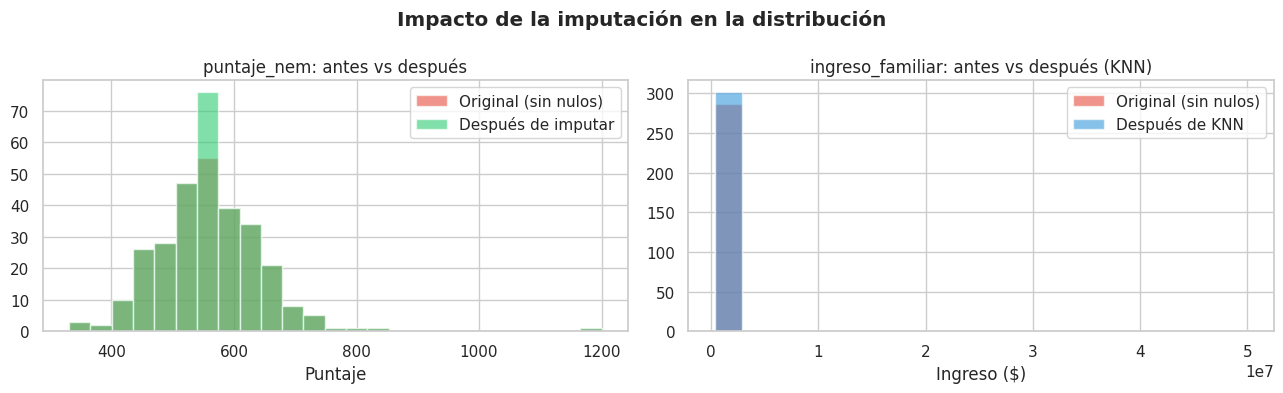

✅ La distribución se mantiene razonable — buena señal.


In [14]:
# Comparación visual: distribución antes y después de imputar
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Puntaje NEM
axes[0].hist(df_raw['puntaje_nem'].dropna(), bins=25,
             alpha=0.6, label='Original (sin nulos)', color='#e74c3c')
axes[0].hist(df['puntaje_nem'], bins=25,
             alpha=0.6, label='Después de imputar', color='#2ecc71')
axes[0].set_title('puntaje_nem: antes vs después')
axes[0].legend()
axes[0].set_xlabel('Puntaje')

# Ingreso familiar (KNN)
axes[1].hist(df_raw['ingreso_familiar'].dropna(), bins=20,
             alpha=0.6, label='Original (sin nulos)', color='#e74c3c')
axes[1].hist(df['ingreso_familiar'], bins=20,
             alpha=0.6, label='Después de KNN', color='#3498db')
axes[1].set_title('ingreso_familiar: antes vs después (KNN)')
axes[1].legend()
axes[1].set_xlabel('Ingreso ($)')

plt.suptitle('Impacto de la imputación en la distribución', fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ La distribución se mantiene razonable — buena señal.')

---

## 🗑️ Sección 3 — Duplicados e Inconsistencias de Texto

In [15]:
# Eliminar duplicados
# keep='first' → conserva la primera ocurrencia, descarta las siguientes

n_antes = len(df)
df = df.drop_duplicates(keep='first').reset_index(drop=True)
n_despues = len(df)

print(f'Filas antes:   {n_antes}')
print(f'Filas después: {n_despues}')
print(f'Eliminadas:    {n_antes - n_despues}')

Filas antes:   303
Filas después: 300
Eliminadas:    3


In [16]:
# Normalización de texto en columnas categóricas
# Estrategia: strip (quitar espacios) + title (primera mayúscula)

cols_categoricas = ['region', 'carrera', 'tipo_colegio']

for col in cols_categoricas:
    df[col] = df[col].str.strip().str.title()

# 'trabaja' tiene valores Sí/No — normalizar a minúscula y mapear
df['trabaja'] = (df['trabaja']
                 .str.strip()
                 .str.lower()
                 .map({'sí': 'Sí', 'si': 'Sí', 'no': 'No'})
)

print('Valores únicos después de normalizar:')
for col in cols_categoricas + ['trabaja']:
    print(f'  {col}: {sorted(df[col].dropna().unique())}')

Valores únicos después de normalizar:
  region: ['Antofagasta', 'Araucanía', 'Biobío', 'Metropolitana', 'Valparaíso']
  carrera: ['Arte', 'Derecho', 'Ingeniería', 'Medicina', 'Pedagogía']
  tipo_colegio: ['Municipal', 'Particular Pagado', 'Particular Subvencionado']
  trabaja: ['No', 'Sí']


---

## 🎯 Sección 4 — Detección y Tratamiento de Outliers

Un outlier es un valor que se aleja mucho del comportamiento esperado. Pero **no todos los outliers son errores** — algunos son casos reales e informativos.

```
Tipos de outliers:
  🔴 Error de entrada   → precio = -9990      → ELIMINAR o corregir
  🟡 Valor inusual real → empresa con ingreso 10× el promedio → CONSERVAR con cuidado
  🟠 Límite de escala   → puntaje = 1200 (máx real es 850)   → ELIMINAR
```

### Dos métodos estándar: IQR y Z-score

In [17]:
# MÉTODO 1: IQR (Rango Intercuartílico)
# Robusto ante distribuciones asimétricas
# Outlier = valor que cae más allá de 1.5 × IQR desde Q1 o Q3

def detectar_outliers_iqr(serie, factor=1.5):
    """Devuelve una máscara booleana: True donde hay outlier."""
    Q1  = serie.quantile(0.25)
    Q3  = serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - factor * IQR
    lim_sup = Q3 + factor * IQR
    return (serie < lim_inf) | (serie > lim_sup)

print('=== Outliers detectados por IQR ===')
for col in ['puntaje_nem', 'ingreso_familiar', 'n_hermanos']:
    mask = detectar_outliers_iqr(df[col])
    n    = mask.sum()
    if n > 0:
        print(f'\n{col}: {n} outlier(s)')
        print(df.loc[mask, ['id', col]])

=== Outliers detectados por IQR ===

puntaje_nem: 5 outlier(s)
      id  puntaje_nem
1      2      331.000
15    16     1200.000
96    97      828.300
119  120      815.200
138  139      336.400

ingreso_familiar: 18 outlier(s)
      id  ingreso_familiar
6      7       2500000.000
58    59       2500000.000
82    83       2500000.000
83    84       2500000.000
88    89      50000000.000
100  101       2500000.000
143  144       2500000.000
146  147       2500000.000
150  151       2500000.000
169  170       2500000.000
173  174       2500000.000
196  197       2500000.000
199  200       2500000.000
226  227       2500000.000
259  260       2500000.000
272  273       2500000.000
285  286       2500000.000
293  294       2500000.000

n_hermanos: 1 outlier(s)
      id  n_hermanos
120  121      25.000


In [18]:
# MÉTODO 2: Z-score
# Bueno cuando la distribución es aproximadamente normal
# Outlier = valor con |z| > 3 (a más de 3 desviaciones estándar de la media)

def detectar_outliers_zscore(serie, umbral=3.0):
    """Devuelve una máscara booleana: True donde hay outlier."""
    media = serie.mean()
    std   = serie.std()
    z     = (serie - media) / std
    return z.abs() > umbral

print('=== Outliers detectados por Z-score (|z| > 3) ===')
for col in ['puntaje_nem', 'ingreso_familiar', 'n_hermanos']:
    mask = detectar_outliers_zscore(df[col])
    n    = mask.sum()
    if n > 0:
        print(f'\n{col}: {n} outlier(s)')
        print(df.loc[mask, ['id', col]])

=== Outliers detectados por Z-score (|z| > 3) ===

puntaje_nem: 2 outlier(s)
    id  puntaje_nem
15  16     1200.000
96  97      828.300

ingreso_familiar: 1 outlier(s)
    id  ingreso_familiar
88  89      50000000.000

n_hermanos: 1 outlier(s)
      id  n_hermanos
120  121      25.000


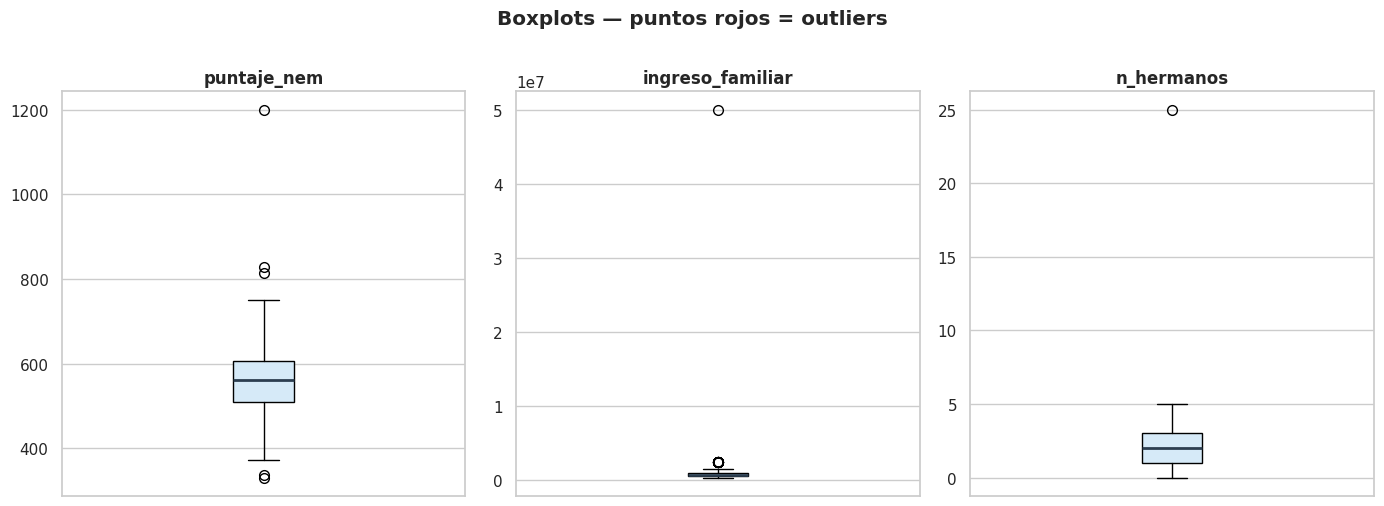

In [19]:
# Visualización: boxplots de las columnas con outliers
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
cols_plot = ['puntaje_nem', 'ingreso_familiar', 'n_hermanos']

for ax, col in zip(axes, cols_plot):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#d6eaf8'),
               medianprops=dict(color='#2c3e50', linewidth=2),
               flierprops=dict(marker='o', color='#e74c3c', markersize=7))
    ax.set_title(col, fontweight='bold')
    ax.set_xticks([])

plt.suptitle('Boxplots — puntos rojos = outliers', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [20]:
# DECISIÓN: qué hacer con cada outlier
#
# puntaje_nem = 1200  → imposible (máximo real es 850) → ELIMINAR la fila
# ingreso_familiar = 50.000.000 → error de captura → ELIMINAR la fila
# n_hermanos = 25    → imposible → ELIMINAR la fila
#
# Alternativa a eliminar: capping (clipear al límite razonable)

n_antes = len(df)

# Eliminar filas con valores imposibles
df = df[df['puntaje_nem'] <= 850]
df = df[df['ingreso_familiar'] <= 10_000_000]
df = df[df['n_hermanos'] <= 10]

df = df.reset_index(drop=True)
print(f'Filas eliminadas por outliers: {n_antes - len(df)}')
print(f'Dataset final: {len(df)} filas')

Filas eliminadas por outliers: 3
Dataset final: 297 filas


In [21]:
# ALTERNATIVA: capping en lugar de eliminar
# Útil cuando no quieres perder filas pero sí limitar el impacto del outlier

df_cap = df.copy()
df_cap['puntaje_nem'] = df_cap['puntaje_nem'].clip(lower=150, upper=850)
df_cap['ingreso_familiar'] = df_cap['ingreso_familiar'].clip(upper=5_000_000)

print('Capping aplicado (sin eliminar filas):')
print(f'  puntaje_nem     → max ahora: {df_cap["puntaje_nem"].max()}')
print(f'  ingreso_familiar → max ahora: {df_cap["ingreso_familiar"].max():,.0f}')
print()
print('Para este dataset continuaremos con df (eliminación).')

Capping aplicado (sin eliminar filas):
  puntaje_nem     → max ahora: 828.3
  ingreso_familiar → max ahora: 2,500,000

Para este dataset continuaremos con df (eliminación).


---

## 🗓️ Sección 5 — Conversión de Tipos y Fechas

In [22]:
# Convertir fecha_nacimiento de string a datetime
print('Tipo antes:', df['fecha_nacimiento'].dtype)
print('Ejemplo:',   df['fecha_nacimiento'].iloc[0])

df['fecha_nacimiento'] = pd.to_datetime(df['fecha_nacimiento'], format='%d/%m/%Y')

print('Tipo después:', df['fecha_nacimiento'].dtype)
print('Ejemplo:',     df['fecha_nacimiento'].iloc[0])

Tipo antes: object
Ejemplo: 01/01/1998
Tipo después: datetime64[ns]
Ejemplo: 1998-01-01 00:00:00


In [23]:
# Extraer componentes de la fecha → feature engineering de fechas
hoy = pd.Timestamp('2024-01-01')

df['edad']             = ((hoy - df['fecha_nacimiento']).dt.days / 365.25).astype(int)
df['anio_nacimiento']  = df['fecha_nacimiento'].dt.year
df['mes_nacimiento']   = df['fecha_nacimiento'].dt.month

print('Nuevas columnas derivadas de fecha:')
print(df[['fecha_nacimiento', 'edad', 'anio_nacimiento', 'mes_nacimiento']].head())

Nuevas columnas derivadas de fecha:
  fecha_nacimiento  edad  anio_nacimiento  mes_nacimiento
0       1998-01-01    25             1998               1
1       1998-01-08    25             1998               1
2       1998-01-15    25             1998               1
3       1998-01-22    25             1998               1
4       1998-01-29    25             1998               1


---

## 🔢 Sección 6 — Codificación de Variables Categóricas

Los modelos de machine learning trabajan con números. Las variables categóricas necesitan ser convertidas.

```
¿Cuándo usar cuál?

LABEL ENCODING                    ONE-HOT ENCODING
──────────────────                ──────────────────────────────
Variable ORDINAL                  Variable NOMINAL
(existe un orden natural)         (no existe orden natural)

Ej: nivel = Bajo / Medio / Alto   Ej: región = Santiago / Temuco
   → 0  /  1   /  2               → columnas binarias separadas

⚠️ Si aplicas Label Encoding a    Desventaja: aumenta el número
   nominal, el modelo creerá      de columnas (curse of dimensionality)
   que Temuco > Santiago.
```

In [24]:
# LABEL ENCODING — para variable ordinal
# tipo_colegio tiene un orden socioeconómico implícito

orden_colegio = {
    'Municipal':                 0,
    'Particular Subvencionado':  1,
    'Particular Pagado':         2
}

df['tipo_colegio_cod'] = df['tipo_colegio'].map(orden_colegio)

print('Label Encoding para tipo_colegio:')
print(df[['tipo_colegio', 'tipo_colegio_cod']].drop_duplicates().sort_values('tipo_colegio_cod'))

Label Encoding para tipo_colegio:
               tipo_colegio  tipo_colegio_cod
2                 Municipal                 0
0  Particular Subvencionado                 1
5         Particular Pagado                 2


In [25]:
# Variable binaria: trabaja Sí/No → 1/0
df['trabaja_num'] = (df['trabaja'] == 'Sí').astype(int)

print('Codificación binaria para trabaja:')
print(df[['trabaja', 'trabaja_num']].drop_duplicates())

Codificación binaria para trabaja:
  trabaja  trabaja_num
0      Sí            1
2      No            0


In [26]:
# ONE-HOT ENCODING — para variables nominales sin orden
# region y carrera no tienen orden natural

df_ohe = pd.get_dummies(df, columns=['region', 'carrera'],
                         prefix=['reg', 'car'],
                         drop_first=True)   # drop_first evita multicolinealidad perfecta

# Columnas nuevas generadas
nuevas = [c for c in df_ohe.columns if c.startswith('reg_') or c.startswith('car_')]
print(f'Columnas antes: {df.shape[1]}')
print(f'Columnas después del OHE: {df_ohe.shape[1]}')
print(f'Nuevas columnas: {nuevas}')
print()
print(df_ohe[nuevas].head(3))

Columnas antes: 17
Columnas después del OHE: 23
Nuevas columnas: ['reg_Araucanía', 'reg_Biobío', 'reg_Metropolitana', 'reg_Valparaíso', 'car_Derecho', 'car_Ingeniería', 'car_Medicina', 'car_Pedagogía']

   reg_Araucanía  reg_Biobío  reg_Metropolitana  reg_Valparaíso  car_Derecho  \
0          False       False               True           False        False   
1          False        True              False           False        False   
2          False       False               True           False        False   

   car_Ingeniería  car_Medicina  car_Pedagogía  
0            True         False          False  
1            True         False          False  
2            True         False          False  


---

## ⚖️ Sección 7 — Normalización y Estandarización

Los algoritmos basados en distancias (KNN, SVM, redes neuronales) son sensibles a la escala de las variables. Si `ingreso_familiar` va de 0 a 5.000.000 y `puntaje_nem` va de 150 a 850, el modelo le dará mucho más peso al ingreso solo por su magnitud.

```
MinMaxScaler (normalización)          StandardScaler (estandarización)
──────────────────────────────        ──────────────────────────────────
Rango resultante: [0, 1]              Resultado: media=0, std=1

x_norm = (x - min) / (max - min)      x_std = (x - media) / std

Úsalo cuando:                         Úsalo cuando:
• Necesitas rango acotado             • La distribución es aprox. normal
• Redes neuronales                    • Comparas variables de distintas unidades
• No hay muchos outliers              • Hay outliers (StandardScaler es más robusto)
```

In [27]:
cols_escalar = ['puntaje_nem', 'puntaje_ranking', 'ingreso_familiar', 'n_hermanos', 'edad']

# MinMaxScaler
mm = MinMaxScaler()
df_minmax = df.copy()
df_minmax[cols_escalar] = mm.fit_transform(df[cols_escalar])

# StandardScaler
ss = StandardScaler()
df_standard = df.copy()
df_standard[cols_escalar] = ss.fit_transform(df[cols_escalar])

# Comparación
print('=== puntaje_nem: comparación de escalas ===')
comparacion = pd.DataFrame({
    'Original':    df['puntaje_nem'].describe(),
    'MinMax':      df_minmax['puntaje_nem'].describe(),
    'Standard':    df_standard['puntaje_nem'].describe(),
})
print(comparacion.round(4))

=== puntaje_nem: comparación de escalas ===
       Original  MinMax  Standard
count   297.000 297.000   297.000
mean    557.330   0.455     0.000
std      77.087   0.155     1.002
min     331.000   0.000    -2.941
25%     509.100   0.358    -0.627
50%     560.500   0.462     0.041
75%     605.600   0.552     0.627
max     828.300   1.000     3.521


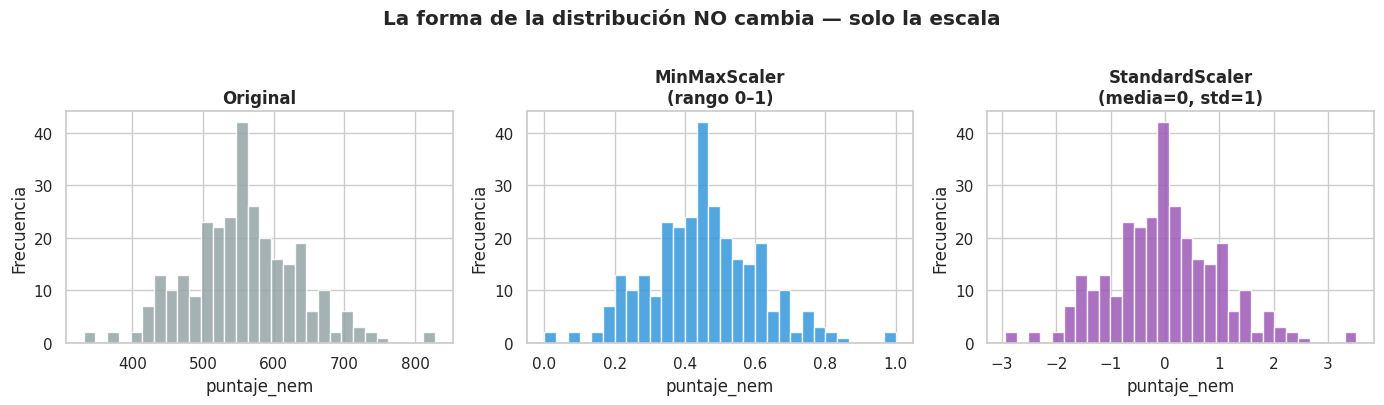

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
col = 'puntaje_nem'

for ax, data, titulo, color in zip(
    axes,
    [df[col], df_minmax[col], df_standard[col]],
    ['Original', 'MinMaxScaler\n(rango 0–1)', 'StandardScaler\n(media=0, std=1)'],
    ['#95a5a6', '#3498db', '#9b59b6']
):
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')

plt.suptitle('La forma de la distribución NO cambia — solo la escala', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

## ⚗️ Sección 8 — Feature Engineering Básico

Feature engineering es el arte de crear nuevas variables a partir de las existentes para darle más información al modelo.

```
Variables originales → Variables derivadas
────────────────────────────────────────────────────────
fecha_nacimiento     → edad, generación, trimestre
ingreso + hermanos   → ingreso_per_capita
puntaje continuo     → categoría (Alto / Medio / Bajo)
texto               → largo del texto, presencia de palabras clave
lat + lon            → distancia a un punto de referencia
```

In [29]:
# Variable derivada 1: ingreso per cápita familiar
df['ingreso_per_capita'] = (df['ingreso_familiar'] / (df['n_hermanos'] + 1)).round(0)

# Variable derivada 2: promedio de puntajes
df['puntaje_promedio'] = ((df['puntaje_nem'] + df['puntaje_ranking']) / 2).round(1)

# Variable derivada 3: binning de puntaje en categorías
bins_puntaje = [0, 499, 599, 699, 850]
labels_puntaje = ['Bajo (<500)', 'Medio (500-599)', 'Alto (600-699)', 'Excelente (700+)']
df['nivel_puntaje'] = pd.cut(df['puntaje_promedio'],
                              bins=bins_puntaje,
                              labels=labels_puntaje)

# Variable derivada 4: indicador de vulnerabilidad
# Combina tipo de colegio e ingreso per cápita
umbral_ingreso = df['ingreso_per_capita'].quantile(0.33)
df['vulnerable'] = (
    (df['tipo_colegio'] == 'Municipal') &
    (df['ingreso_per_capita'] < umbral_ingreso)
).astype(int)

print('Nuevas variables creadas:')
print(df[['ingreso_familiar', 'n_hermanos', 'ingreso_per_capita',
          'puntaje_promedio', 'nivel_puntaje', 'vulnerable']].head(8))

Nuevas variables creadas:
   ingreso_familiar  n_hermanos  ingreso_per_capita  puntaje_promedio  \
0       1000000.000       0.000         1000000.000           615.400   
1        350000.000       4.000           70000.000           432.000   
2       1500000.000       4.000          300000.000           552.000   
3        500000.000       1.000          250000.000           573.400   
4        700000.000       3.000          175000.000           476.800   
5       1500000.000       2.000          500000.000           557.900   
6       2500000.000       2.000          833333.000           549.800   
7       1000000.000       3.000          250000.000           633.400   

     nivel_puntaje  vulnerable  
0   Alto (600-699)           0  
1      Bajo (<500)           0  
2  Medio (500-599)           0  
3  Medio (500-599)           0  
4      Bajo (<500)           0  
5  Medio (500-599)           0  
6  Medio (500-599)           0  
7   Alto (600-699)           0  


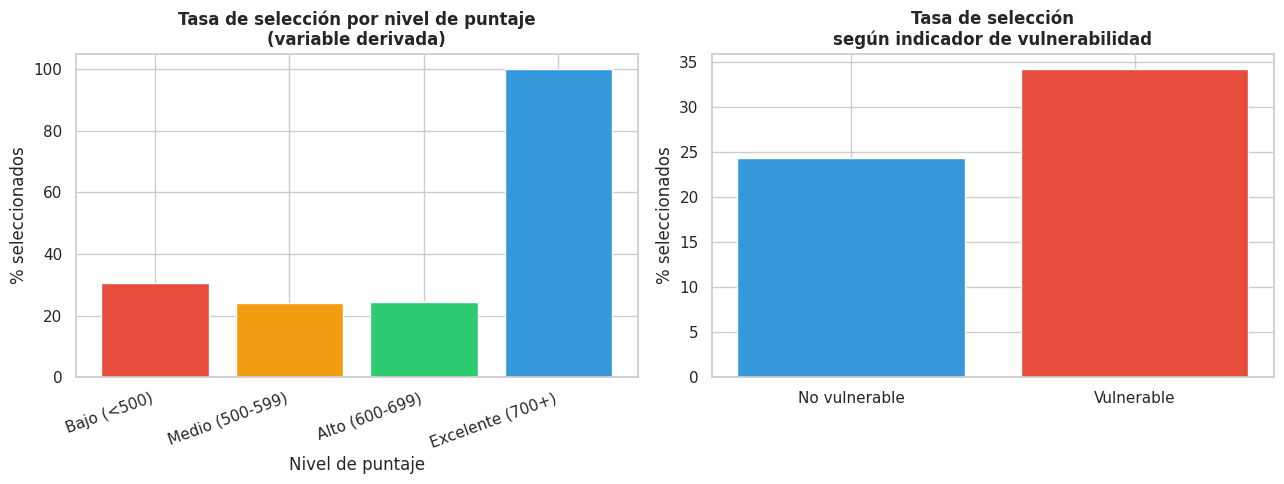

In [30]:
# ¿El feature engineering captura algo útil?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Nivel de puntaje vs selección
tasa_seleccion = df.groupby('nivel_puntaje', observed=True)['seleccionado'].mean() * 100
axes[0].bar(tasa_seleccion.index, tasa_seleccion.values,
            color=['#e74c3c','#f39c12','#2ecc71','#3498db'], edgecolor='white')
axes[0].set_title('Tasa de selección por nivel de puntaje\n(variable derivada)', fontweight='bold')
axes[0].set_ylabel('% seleccionados')
axes[0].set_xlabel('Nivel de puntaje')
plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right')

# Vulnerabilidad vs selección
tasa_vul = df.groupby('vulnerable')['seleccionado'].mean() * 100
axes[1].bar(['No vulnerable', 'Vulnerable'], tasa_vul.values,
            color=['#3498db', '#e74c3c'], edgecolor='white')
axes[1].set_title('Tasa de selección\nsegún indicador de vulnerabilidad', fontweight='bold')
axes[1].set_ylabel('% seleccionados')

plt.tight_layout()
plt.show()

---

## 🔧 Sección 9 — Pipeline de Preprocesamiento con scikit-learn

Un **Pipeline** encadena pasos de preprocesamiento para que se apliquen automáticamente en orden. Es la forma profesional de preprocesar datos porque:

1. Garantiza que train y test reciban exactamente la misma transformación
2. Evita data leakage (filtrar información del test al train)
3. Es reproducible y fácil de auditar

```
         fit(X_train) → aprende parámetros (media, min, max...)
Pipeline ─┤
         transform(X_test) → aplica los mismos parámetros
```

In [31]:
from sklearn.model_selection import train_test_split

# Preparar el dataset para el pipeline
# Seleccionamos columnas representativas
cols_num_pipe = ['puntaje_nem', 'puntaje_ranking', 'ingreso_familiar',
                 'n_hermanos', 'edad']
cols_cat_pipe = ['tipo_colegio', 'region', 'carrera']

X = df[cols_num_pipe + cols_cat_pipe + ['trabaja_num', 'vulnerable']].copy()
y = df['seleccionado'].copy()

# Asegurar que no hay nulos antes del pipeline
print(f'Nulos en X antes del pipeline: {X.isnull().sum().sum()}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Nulos en X antes del pipeline: 0
Train: (237, 10)  |  Test: (60, 10)


In [32]:
# Pipeline separado por tipo de columna

# Rama numérica: imputar mediana → estandarizar
pipeline_num = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Rama categórica: imputar moda → one-hot encode
pipeline_cat = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer: aplica cada pipeline a sus columnas
preprocesador = ColumnTransformer(transformers=[
    ('num', pipeline_num, cols_num_pipe),
    ('cat', pipeline_cat, cols_cat_pipe),
], remainder='passthrough')   # columnas restantes pasan sin cambio

# Ajustar sobre train, transformar train y test
X_train_proc = preprocesador.fit_transform(X_train)
X_test_proc  = preprocesador.transform(X_test)

print(f'X_train transformado: {X_train_proc.shape}')
print(f'X_test  transformado: {X_test_proc.shape}')
print()
print('✅ Mismo preprocesador ajustado en train, aplicado en test.')
print('   Esto evita data leakage.')

X_train transformado: (237, 20)
X_test  transformado: (60, 20)

✅ Mismo preprocesador ajustado en train, aplicado en test.
   Esto evita data leakage.


In [33]:
# Ver la estructura del pipeline
from sklearn import set_config
set_config(display='text')
print(preprocesador)

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['puntaje_nem', 'puntaje_ranking',
                                  'ingreso_familiar', 'n_hermanos', 'edad']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['tipo_colegio', 'region', 'carrera'])])


---

## 🛠️ Sección 10 — Taller: Checklist de Limpieza para tu Dataset

Ahora aplica todo lo que vimos a tu propio dataset. Sigue la checklist en orden y documenta cada decisión.

> 📌 **Regla de oro:** cada decisión de limpieza debe poder justificarse. Si no puedes explicar por qué hiciste algo, probablemente no deberías haberlo hecho.

In [ ]:
# ── CARGA TU DATASET ──────────────────────────────────────────────────────
from google.colab import files

uploaded = files.upload()
nombre_archivo = list(uploaded.keys())[0]

if nombre_archivo.endswith('.csv'):
    df_mio = pd.read_csv(nombre_archivo)
elif nombre_archivo.endswith('.json'):
    df_mio = pd.read_json(nombre_archivo)
elif nombre_archivo.endswith(('.xlsx', '.xls')):
    df_mio = pd.read_excel(nombre_archivo)
elif nombre_archivo.endswith('.parquet'):
    df_mio = pd.read_parquet(nombre_archivo)

df_original = df_mio.copy()   # conservar el original sin modificar
print(f'✅ Dataset cargado: {df_mio.shape[0]} filas × {df_mio.shape[1]} columnas')

---
### ☑️ ÍTEM 1 — Diagnóstico inicial

In [ ]:
nulos = df_mio.isnull().sum()
pct   = (nulos / len(df_mio) * 100).round(1)

diag = pd.DataFrame({
    'Nulos': nulos,
    '%_nulos': pct,
    'Tipo': df_mio.dtypes,
    'Únicos': df_mio.nunique(),
})

print('=== DIAGNÓSTICO COMPLETO ===')
print(diag.to_string())
print()
print(f'Duplicados: {df_mio.duplicated().sum()}')

✏️ **Decisión 1 — Diagnóstico:**  
*¿Cuántos nulos encontraste? ¿En qué columnas? ¿Detectas algún patrón en los nulos? ¿Hay duplicados? ¿Hay tipos de datos incorrectos?*

```
Escribe aquí tu análisis:
- Nulos: ...
- Duplicados: ...
- Tipos incorrectos: ...
- Observación sobre patrones: ...
```

---
### ☑️ ÍTEM 2 — Duplicados

In [ ]:
n_antes = len(df_mio)

df_mio = df_mio.drop_duplicates(keep='first').reset_index(drop=True)

print(f'Duplicados eliminados: {n_antes - len(df_mio)}')
print(f'Filas restantes: {len(df_mio)}')

✏️ **Decisión 2 — Duplicados:**  
*¿Cuántos duplicados eliminaste? ¿Eran filas completamente iguales o había alguna diferencia? ¿La eliminación tuvo sentido en el contexto de tus datos?*

---
### ☑️ ÍTEM 3 — Consistencia de texto

In [ ]:
# Inspeccionar columnas de texto (object)
cols_obj = df_mio.select_dtypes('object').columns.tolist()
print(f'Columnas de texto: {cols_obj}')
print()

for col in cols_obj[:6]:   # primeras 6 para no llenar la pantalla
    n_unicos = df_mio[col].nunique()
    print(f'{col} ({n_unicos} únicos):')
    if n_unicos <= 20:
        print(f'  {sorted(df_mio[col].dropna().unique())}')
    else:
        print(f'  (demasiados para listar — muestra: {df_mio[col].dropna().sample(5, random_state=1).tolist()})')
    print()

In [ ]:
# Normalización general: strip + title para columnas categóricas
# Ajusta esta lista según lo que encontraste en la celda de arriba

cols_normalizar = []  # ← agrega aquí las columnas que necesitan normalización
# Ejemplo: cols_normalizar = ['ciudad', 'categoria']

for col in cols_normalizar:
    antes = df_mio[col].nunique()
    df_mio[col] = df_mio[col].str.strip().str.title()
    despues = df_mio[col].nunique()
    print(f'{col}: {antes} → {despues} valores únicos')

if not cols_normalizar:
    print('(no se seleccionaron columnas para normalizar — completa la lista)')

✏️ **Decisión 3 — Texto:**  
*¿Encontraste inconsistencias? ¿Qué columnas normalizaste? ¿Quedaron categorías que deberían ser la misma pero siguen apareciendo separadas?*

---
### ☑️ ÍTEM 4 — Tipos de datos

In [ ]:
# Convertir columnas según corresponda
# Descomenta y ajusta según tu dataset

# Fechas
# df_mio['fecha'] = pd.to_datetime(df_mio['fecha'], format='%Y-%m-%d')

# Números que vienen como texto
# df_mio['precio'] = pd.to_numeric(df_mio['precio'], errors='coerce')

# Enteros que deberian serlo
# df_mio['cantidad'] = df_mio['cantidad'].astype(int)

print('Tipos de datos actuales:')
print(df_mio.dtypes)

✏️ **Decisión 4 — Tipos:**  
*¿Qué conversiones hiciste? ¿Había columnas numéricas guardadas como texto? ¿Tenías fechas? ¿Qué formato tenían?*

---
### ☑️ ÍTEM 5 — Outliers

In [ ]:
# Detectar outliers en columnas numéricas con IQR
cols_num_mio = df_mio.select_dtypes(include='number').columns.tolist()
print(f'Columnas numéricas: {cols_num_mio}')
print()

print('=== Rangos (min / max) ===')
for col in cols_num_mio:
    print(f'  {col:<30} min={df_mio[col].min():>12,.2f}   max={df_mio[col].max():>12,.2f}')

In [ ]:
# Boxplots rápidos de todas las columnas numéricas
n_cols = len(cols_num_mio)
if n_cols > 0:
    n_filas = (n_cols + 2) // 3
    fig, axes = plt.subplots(n_filas, 3, figsize=(14, 4 * n_filas))
    axes = axes.flatten()

    for i, col in enumerate(cols_num_mio):
        axes[i].boxplot(df_mio[col].dropna(), patch_artist=True,
                        boxprops=dict(facecolor='#d6eaf8'),
                        medianprops=dict(color='#2c3e50', linewidth=2),
                        flierprops=dict(marker='o', color='#e74c3c', markersize=6))
        axes[i].set_title(col, fontweight='bold', fontsize=10)
        axes[i].set_xticks([])

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Boxplots — identifica outliers (puntos rojos)', fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# Tratar outliers — ajusta según lo que encontraste
# Opciones:
#   1. Eliminar filas:  df_mio = df_mio[df_mio['col'] <= limite]
#   2. Capping:         df_mio['col'] = df_mio['col'].clip(upper=limite)
#   3. No hacer nada:  si el outlier es un valor real e importante

n_antes = len(df_mio)

# Escribe aquí tu tratamiento:
# df_mio = df_mio[df_mio['mi_columna'] >= 0]   # eliminar negativos imposibles
# df_mio['mi_columna'] = df_mio['mi_columna'].clip(upper=LIMITE)

print(f'Filas antes: {n_antes}  →  después: {len(df_mio)}')

✏️ **Decisión 5 — Outliers:**  
*¿Qué outliers encontraste? Para cada uno: ¿es un error o un valor real? ¿Qué decidiste hacer (eliminar, capping, conservar)? ¿Por qué?*

---
### ☑️ ÍTEM 6 — Tratamiento de nulos

In [ ]:
# Resumen de nulos actualizado (después de limpieza anterior)
nulos_actual = df_mio.isnull().sum()
print('Nulos que quedan por columna:')
print(nulos_actual[nulos_actual > 0])

In [ ]:
# Estrategia de imputación — ajusta según tu dataset
# Opciones comentadas a continuación:

cols_num_mio_actual = df_mio.select_dtypes(include='number').columns.tolist()

# Imputar numéricas con mediana
if cols_num_mio_actual:
    imp_med = SimpleImputer(strategy='median')
    df_mio[cols_num_mio_actual] = imp_med.fit_transform(df_mio[cols_num_mio_actual])

# Imputar categóricas con la moda
cols_cat_mio = df_mio.select_dtypes('object').columns.tolist()
if cols_cat_mio:
    imp_moda = SimpleImputer(strategy='most_frequent')
    df_mio[cols_cat_mio] = imp_moda.fit_transform(df_mio[cols_cat_mio])

print('Nulos después de imputación:')
print(df_mio.isnull().sum().sum(), 'nulos totales')

✏️ **Decisión 6 — Nulos:**  
*¿Qué estrategia usaste para cada columna con nulos? ¿Por qué eligiste mediana/media/moda? ¿Consideraste KNN para alguna? ¿Cuántas filas habrías perdido con dropna()?*

---
### ☑️ ÍTEM 7 — Feature Engineering

In [ ]:
# Crea al menos 1-2 variables derivadas relevantes para tu pregunta
# Ejemplos según tipo de datos:

# Si tienes fechas:
# df_mio['anio'] = pd.to_datetime(df_mio['fecha']).dt.year
# df_mio['mes']  = pd.to_datetime(df_mio['fecha']).dt.month

# Si tienes dos columnas numéricas:
# df_mio['ratio'] = df_mio['col_a'] / df_mio['col_b']

# Si quieres categorizar una variable continua:
# df_mio['nivel'] = pd.cut(df_mio['mi_col'], bins=3, labels=['Bajo','Medio','Alto'])

print('Columnas actuales del dataset:')
print(df_mio.columns.tolist())

# Escribe tu feature engineering aquí:

✏️ **Decisión 7 — Feature Engineering:**  
*¿Qué variables nuevas creaste? ¿Por qué crees que son informativas para tu pregunta de investigación?*

---
### ☑️ ÍTEM 8 — Dataset final limpio

In [ ]:
print('=======================================================')
print('  COMPARACIÓN: ANTES vs DESPUÉS DE LA LIMPIEZA')
print('=======================================================')
print(f'  Filas:    {df_original.shape[0]:>6}  →  {df_mio.shape[0]:>6}')
print(f'  Columnas: {df_original.shape[1]:>6}  →  {df_mio.shape[1]:>6}')
print(f'  Nulos:    {df_original.isnull().sum().sum():>6}  →  {df_mio.isnull().sum().sum():>6}')
print(f'  Dupl.:    {df_original.duplicated().sum():>6}  →  {df_mio.duplicated().sum():>6}')
print('=======================================================')

# Guardar dataset limpio
nombre_limpio = nombre_archivo.replace('.csv', '_limpio.csv').replace('.xlsx', '_limpio.csv')
df_mio.to_csv(nombre_limpio, index=False, encoding='utf-8')
print(f'\n✅ Dataset limpio guardado como: {nombre_limpio}')

In [ ]:
# Descargar el dataset limpio a tu computador
files.download(nombre_limpio)

In [ ]:
# Ficha de decisiones tomadas — COMPLETA ESTO ANTES DE TERMINAR

mi_nombre       = "Tu nombre"
mi_dataset      = "Nombre del dataset"
decision_nulos  = "Explica qué hiciste con los nulos y por qué"
decision_outl   = "Explica qué hiciste con los outliers y por qué"
decision_fe     = "Describe las variables nuevas que creaste"
pregunta_ajuste = "¿Necesitas ajustar tu pregunta de investigación después de ver los datos limpios?"

print('='*65)
print('  FICHA DE LIMPIEZA — CLASE 3')
print('='*65)
print(f'  Alumna/o: {mi_nombre}')
print(f'  Dataset:  {mi_dataset}')
print()
print(f'  Nulos:    {decision_nulos}')
print(f'  Outliers: {decision_outl}')
print(f'  FE:       {decision_fe}')
print(f'  Pregunta: {pregunta_ajuste}')
print('='*65)
print(f'  Dataset final: {df_mio.shape[0]} filas × {df_mio.shape[1]} columnas')

---

## ✅ Resumen de la Clase 3

| Tema | Lo esencial |
|---|---|
| **Diagnóstico** | Siempre empieza aquí. Nulos + duplicados + inconsistencias + outliers antes de tocar nada |
| **Nulos** | Eliminar si son pocos y aleatorios. Imputar con mediana/moda si son moderados. KNN si tienen patrón |
| **Outliers** | IQR para distribuciones asimétricas, Z-score para normales. Decide caso a caso: eliminar vs capping vs conservar |
| **Texto** | `.str.strip().str.title()` resuelve el 80% de las inconsistencias de mayúsculas |
| **Codificación** | Label Encoding para ordinales, One-Hot para nominales, binaria (0/1) para sí/no |
| **Escalado** | MinMaxScaler si necesitas rango [0,1]. StandardScaler si la distribución es normal o hay outliers |
| **Feature Engineering** | Fechas → componentes. Ratios entre columnas. Binning. Indicadores compuestos |
| **Pipeline** | `ColumnTransformer` + `Pipeline` = preprocesamiento reproducible sin data leakage |

---

**Próxima sesión — Clase 4:** Análisis Exploratorio de Datos (EDA). Con el dataset ya limpio, vamos a buscar patrones, correlaciones y respuestas preliminares a tu pregunta de investigación.

**Tarea:** Trae tu dataset limpio (el archivo `_limpio.csv`) guardado y la ficha de decisiones completa.

---
*Notebook elaborado para el curso Introducción a la Ciencia de Datos · Sesión 3*